# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Emotional and Psychological State Dataset](https://www.kaggle.com/datasets/ziya07/student-emotional-and-psychological-state-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('psychological_regulation_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Year,Department,Sleep_Hours,Screen_Time,Attendance,Assignment_Load,Exam_Pressure,...,Heart_Rate,Stress_Score,Stress_Level,Anxiety_Score,Anxiety_Level,Mood_State,Previous_Intervention,Intervention_Response,Reward_Score,Final_State
0,1,24,Other,1st,CSE,8.0,3.5,90.1,5,7,...,112,4.75,Medium,3.92,Low,Neutral,Stretching Suggestion,0.68,7.50,Relaxed
1,2,19,Male,2nd,ECE,7.6,9.5,55.0,5,1,...,86,2.69,Low,2.20,Low,Calm,No Action,0.38,6.82,Neutral
2,3,20,Other,1st,BBA,5.9,9.9,76.0,5,3,...,73,4.10,Medium,3.73,Low,Neutral,Motivational Message,0.74,7.46,Relaxed
3,4,21,Male,2nd,ARTS,5.2,7.5,82.4,8,3,...,65,5.28,Medium,4.98,Medium,Neutral,Motivational Message,0.56,4.89,Stress
4,5,19,Male,4th,MECH,7.9,9.5,95.3,8,7,...,77,6.21,Medium,4.43,Medium,Neutral,Peer Support,0.66,6.62,Neutral


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Academic_Year,Department,Sleep_Hours,Screen_Time,Attendance,Assignment_Load,Exam_Pressure,...,Heart_Rate,Stress_Score,Stress_Level,Anxiety_Score,Anxiety_Level,Mood_State,Previous_Intervention,Intervention_Response,Reward_Score,Final_State
9995,9996,21,Other,1st,EEE,8.2,4.8,65.7,9,8,...,102,6.51,Medium,4.78,Medium,Neutral,Stretching Suggestion,0.53,5.65,Neutral
9996,9997,19,Female,1st,ECE,4.7,8.7,95.1,4,10,...,79,6.70,Medium,5.49,Medium,Fatigued,Stretching Suggestion,0.66,6.62,Neutral
9997,9998,24,Other,4th,CIVIL,4.9,5.0,61.1,1,4,...,108,3.16,Low,4.04,Medium,Fatigued,No Action,0.46,6.44,Neutral
9998,9999,24,Female,1st,CIVIL,6.2,2.3,58.1,5,10,...,64,6.26,Medium,4.80,Medium,Neutral,Motivational Message,0.58,6.20,Neutral
9999,10000,22,Female,2nd,EEE,7.3,9.4,80.4,1,3,...,92,3.21,Low,4.48,Medium,Calm,No Action,0.27,4.87,Stress


## Shape of our dataset

In [5]:
df.shape

(10000, 25)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Year', 'Department',
       'Sleep_Hours', 'Screen_Time', 'Attendance', 'Assignment_Load',
       'Exam_Pressure', 'Social_Support', 'Physical_Activity',
       'Caffeine_Intake', 'Study_Hours', 'Facial_Emotion', 'Heart_Rate',
       'Stress_Score', 'Stress_Level', 'Anxiety_Score', 'Anxiety_Level',
       'Mood_State', 'Previous_Intervention', 'Intervention_Response',
       'Reward_Score', 'Final_State'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                 int64
Age                        int64
Gender                    object
Academic_Year             object
Department                object
Sleep_Hours              float64
Screen_Time              float64
Attendance               float64
Assignment_Load            int64
Exam_Pressure              int64
Social_Support             int64
Physical_Activity        float64
Caffeine_Intake            int64
Study_Hours              float64
Facial_Emotion            object
Heart_Rate                 int64
Stress_Score             float64
Stress_Level              object
Anxiety_Score            float64
Anxiety_Level             object
Mood_State                object
Previous_Intervention     object
Intervention_Response    float64
Reward_Score             float64
Final_State               object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  int64  
 2   Gender                 10000 non-null  object 
 3   Academic_Year          10000 non-null  object 
 4   Department             10000 non-null  object 
 5   Sleep_Hours            10000 non-null  float64
 6   Screen_Time            10000 non-null  float64
 7   Attendance             10000 non-null  float64
 8   Assignment_Load        10000 non-null  int64  
 9   Exam_Pressure          10000 non-null  int64  
 10  Social_Support         10000 non-null  int64  
 11  Physical_Activity      10000 non-null  float64
 12  Caffeine_Intake        10000 non-null  int64  
 13  Study_Hours            10000 non-null  float64
 14  Facial_Emotion         10000 non-null  object 
 15  Hea

## Check Null Value

In [9]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Academic_Year            0
Department               0
Sleep_Hours              0
Screen_Time              0
Attendance               0
Assignment_Load          0
Exam_Pressure            0
Social_Support           0
Physical_Activity        0
Caffeine_Intake          0
Study_Hours              0
Facial_Emotion           0
Heart_Rate               0
Stress_Score             0
Stress_Level             0
Anxiety_Score            0
Anxiety_Level            0
Mood_State               0
Previous_Intervention    0
Intervention_Response    0
Reward_Score             0
Final_State              0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Student_ID,Age,Sleep_Hours,Screen_Time,Attendance,Assignment_Load,Exam_Pressure,Social_Support,Physical_Activity,Caffeine_Intake,Study_Hours,Heart_Rate,Stress_Score,Anxiety_Score,Intervention_Response,Reward_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,22.510500,6.486910,6.036260,77.400230,5.03740,5.502100,5.560700,1.001780,2.485000,4.529130,87.032700,4.934160,4.660822,0.575127,6.014137
std,2886.89568,2.885814,1.440041,2.322369,12.961707,2.59682,2.887357,2.883808,0.580588,1.690462,2.021563,15.775688,1.501476,1.288043,0.174148,0.824635
min,1.00000,18.000000,4.000000,2.000000,55.000000,1.00000,1.000000,1.000000,0.000000,0.000000,1.000000,60.000000,1.050000,1.270000,0.200000,3.710000
25%,2500.75000,20.000000,5.200000,4.000000,66.175000,3.00000,3.000000,3.000000,0.500000,1.000000,2.800000,73.000000,3.810000,3.740000,0.460000,5.420000
50%,5000.50000,23.000000,6.500000,6.100000,77.500000,5.00000,6.000000,6.000000,1.000000,2.000000,4.600000,87.000000,4.910000,4.660000,0.600000,6.010000
75%,7500.25000,25.000000,7.700000,8.000000,88.600000,7.00000,8.000000,8.000000,1.500000,4.000000,6.200000,101.000000,6.080000,5.590000,0.710000,6.610000
max,10000.00000,27.000000,9.000000,10.000000,100.000000,9.00000,10.000000,10.000000,2.000000,5.000000,8.000000,114.000000,8.890000,8.200000,0.950000,8.320000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

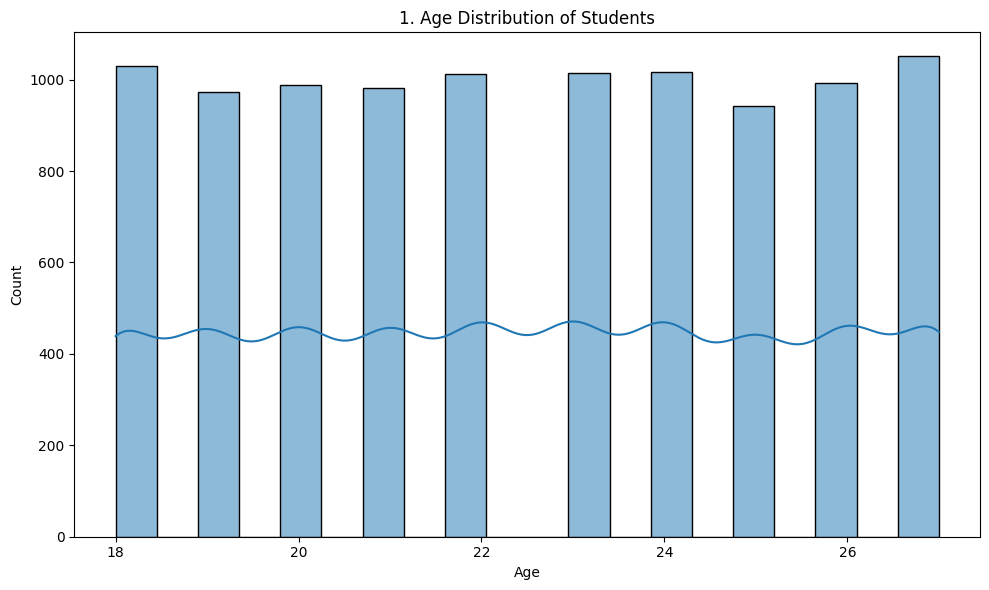

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Students')
show_fig()
plot_no += 1

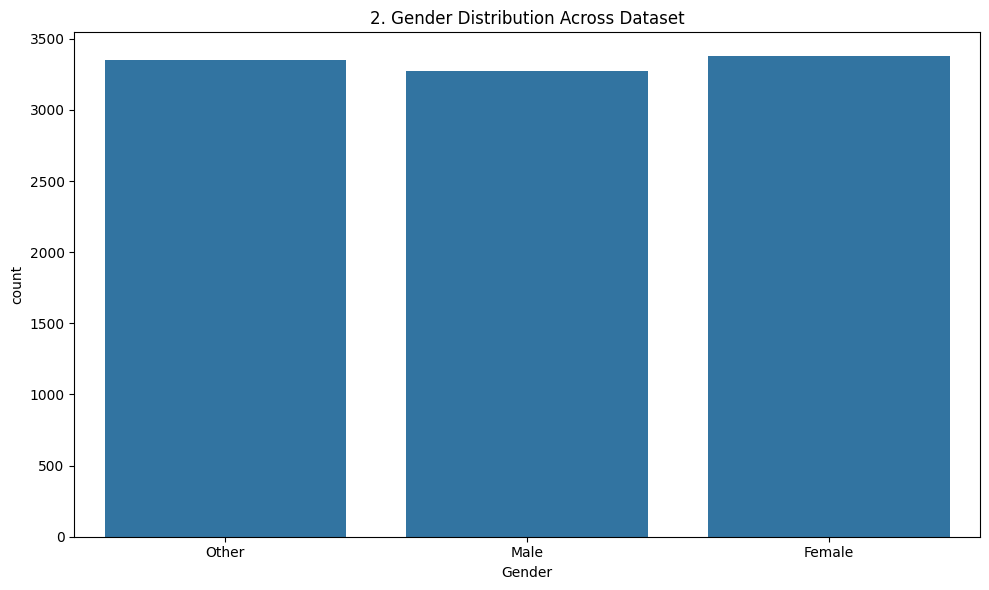

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title(f'{plot_no}. Gender Distribution Across Dataset')
show_fig()
plot_no += 1

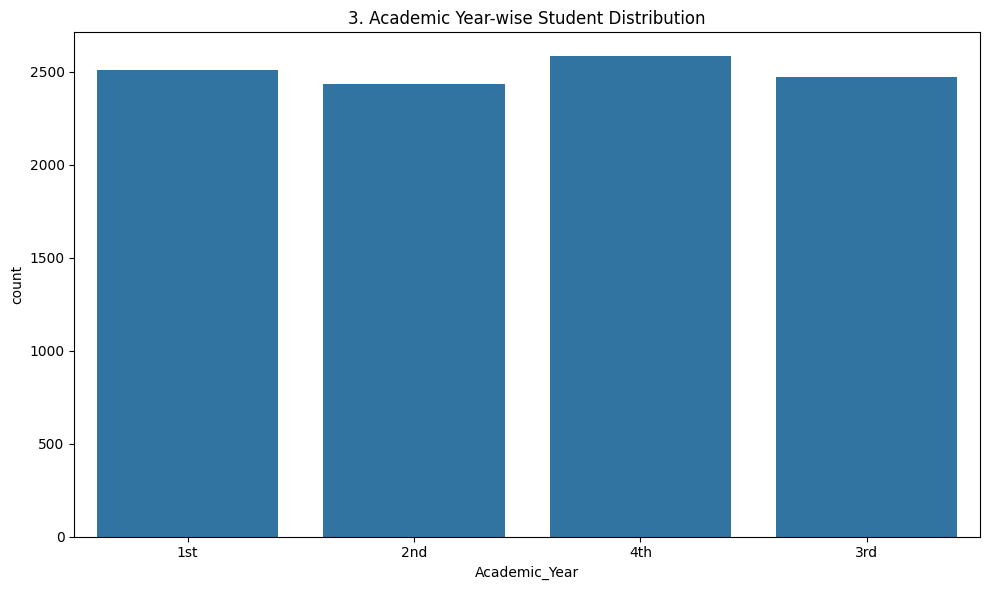

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Academic_Year', data=df)
plt.title(f'{plot_no}. Academic Year-wise Student Distribution')
show_fig()
plot_no += 1

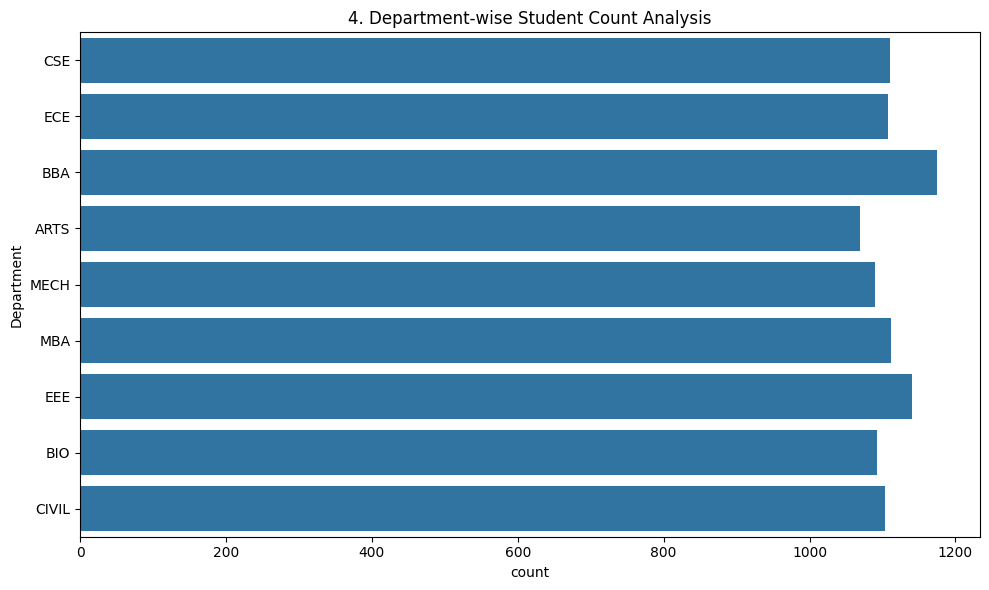

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Department', data=df)
plt.title(f'{plot_no}. Department-wise Student Count Analysis')
show_fig()
plot_no += 1

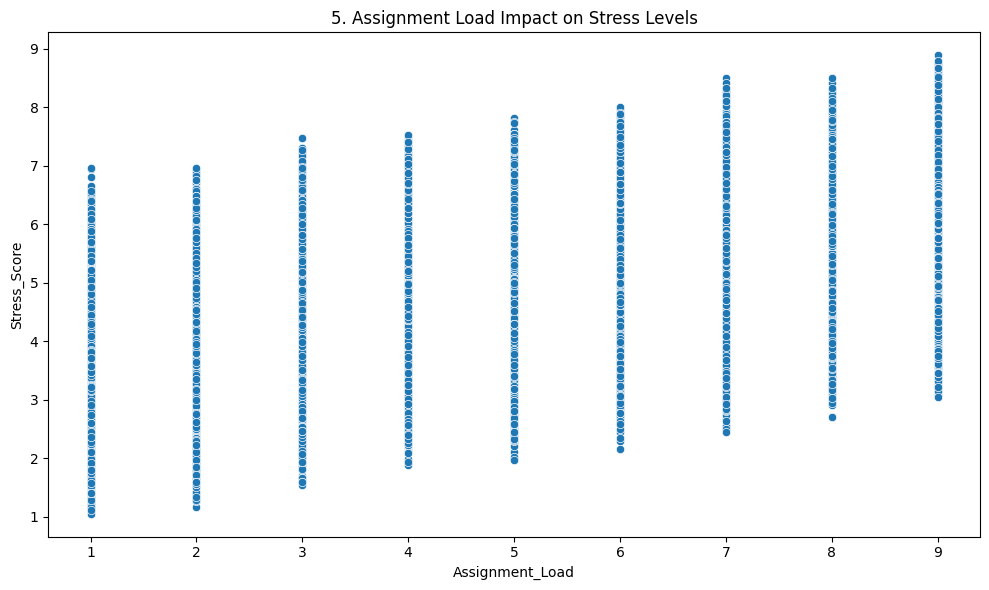

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Assignment_Load', y='Stress_Score', data=df)
plt.title(f'{plot_no}. Assignment Load Impact on Stress Levels')
show_fig()
plot_no += 1

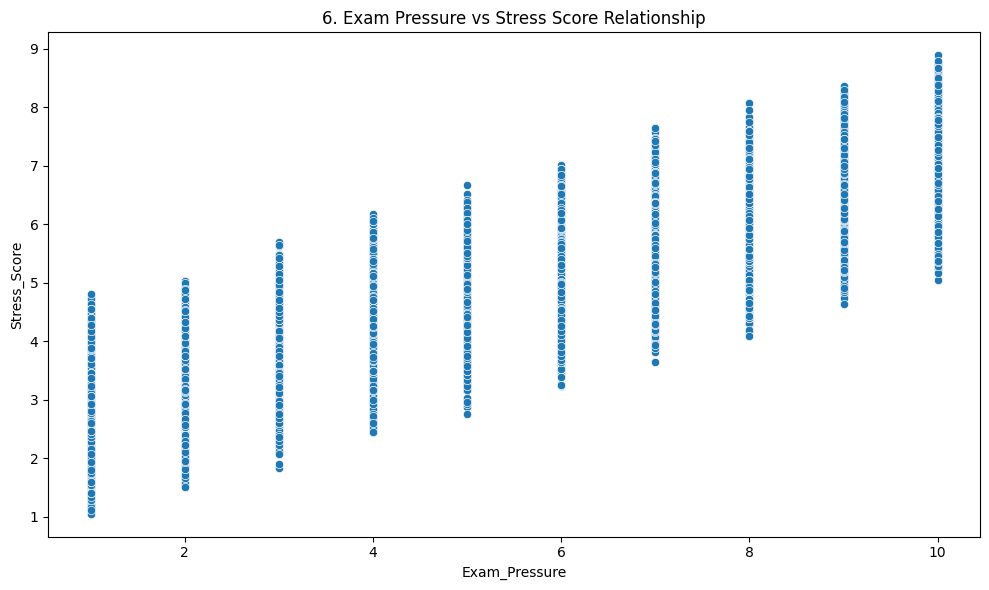

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Exam_Pressure', y='Stress_Score', data=df)
plt.title(f'{plot_no}. Exam Pressure vs Stress Score Relationship')
show_fig()
plot_no += 1

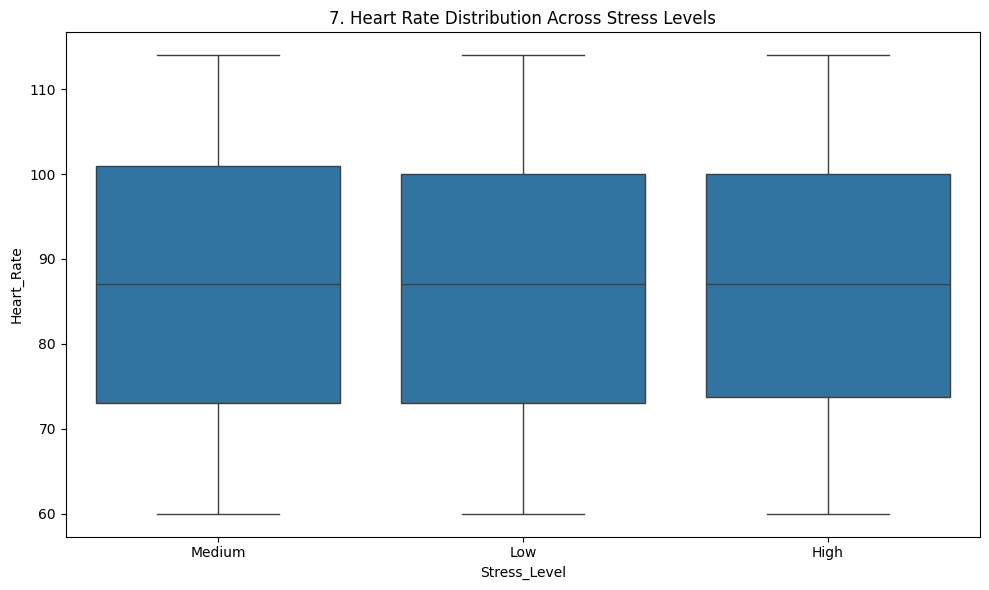

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Stress_Level', y='Heart_Rate', data=df)
plt.title(f'{plot_no}. Heart Rate Distribution Across Stress Levels')
show_fig()
plot_no += 1

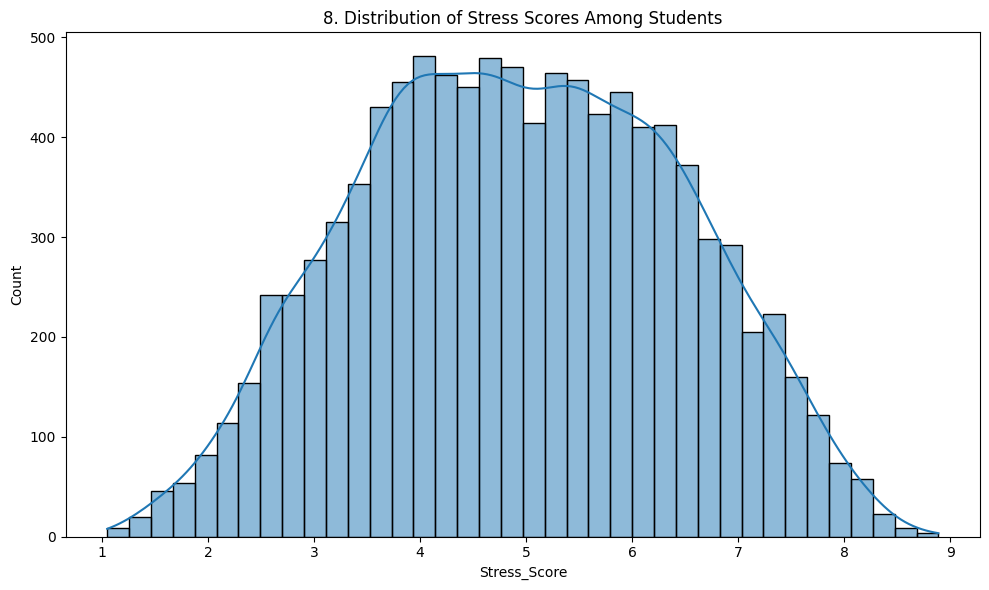

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Stress_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Stress Scores Among Students')
show_fig()
plot_no += 1

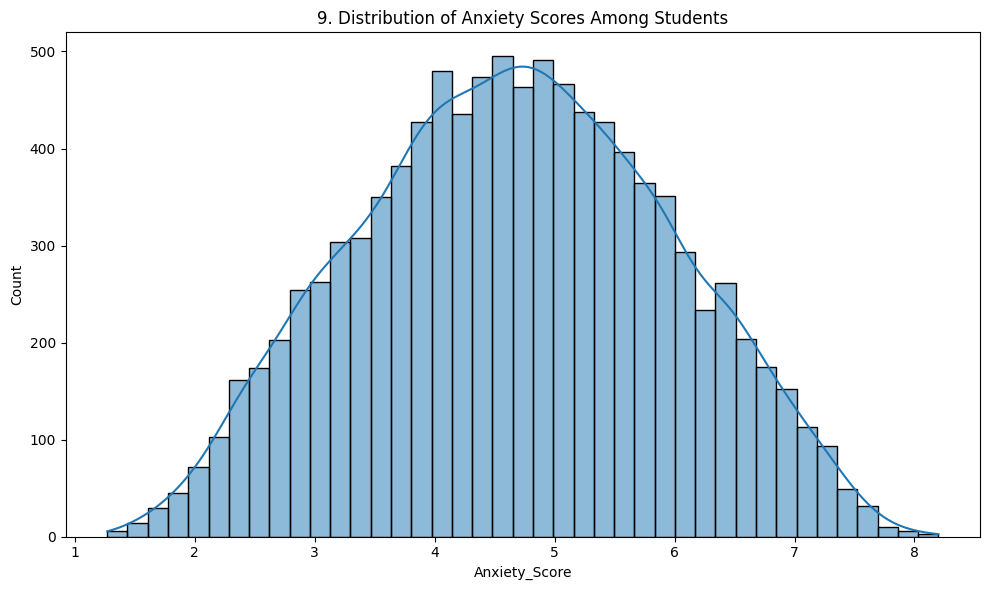

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Anxiety_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Anxiety Scores Among Students')
show_fig()
plot_no += 1

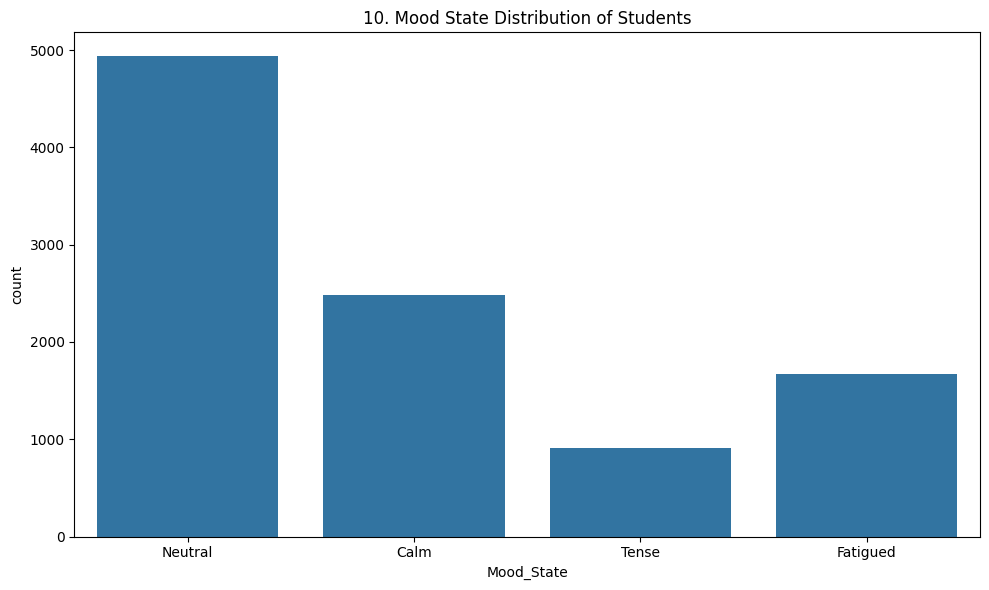

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Mood_State', data=df)
plt.title(f'{plot_no}. Mood State Distribution of Students')
show_fig()
plot_no += 1

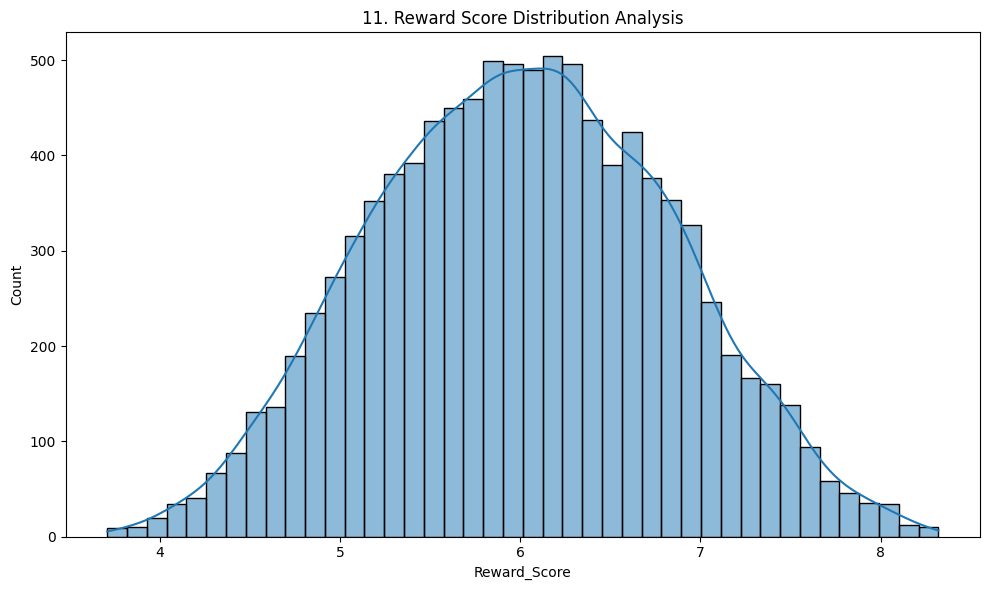

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Reward_Score'], kde=True)
plt.title(f'{plot_no}. Reward Score Distribution Analysis')
show_fig()
plot_no += 1

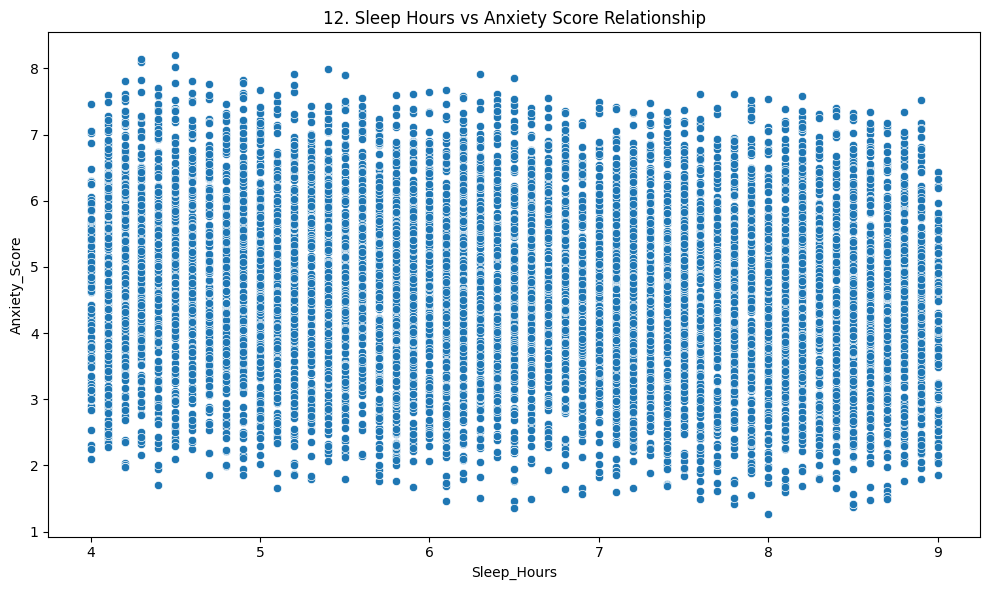

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Sleep_Hours', y='Anxiety_Score', data=df)
plt.title(f'{plot_no}. Sleep Hours vs Anxiety Score Relationship')
show_fig()
plot_no += 1

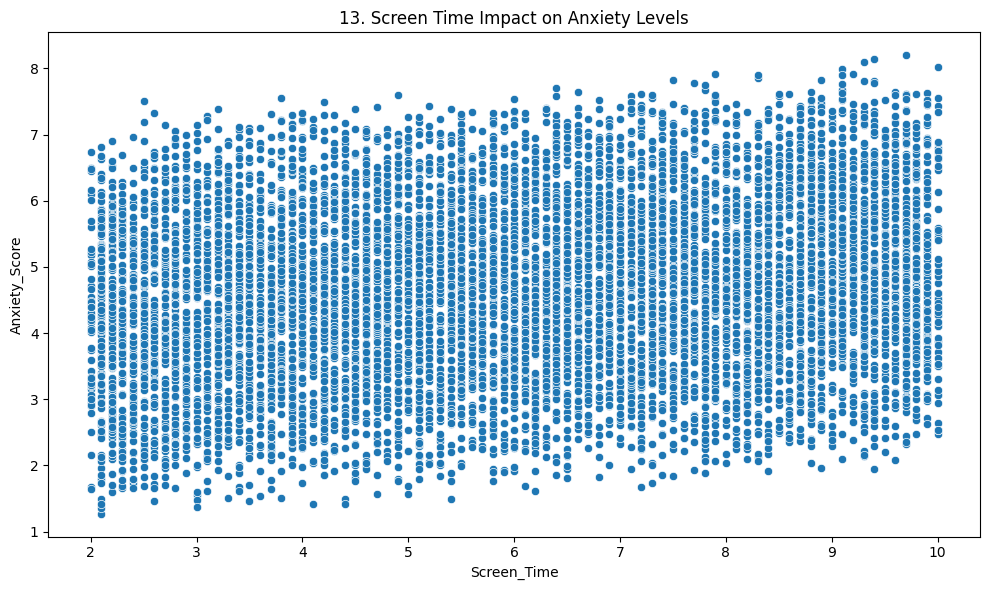

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Screen_Time', y='Anxiety_Score', data=df)
plt.title(f'{plot_no}. Screen Time Impact on Anxiety Levels')
show_fig()
plot_no += 1

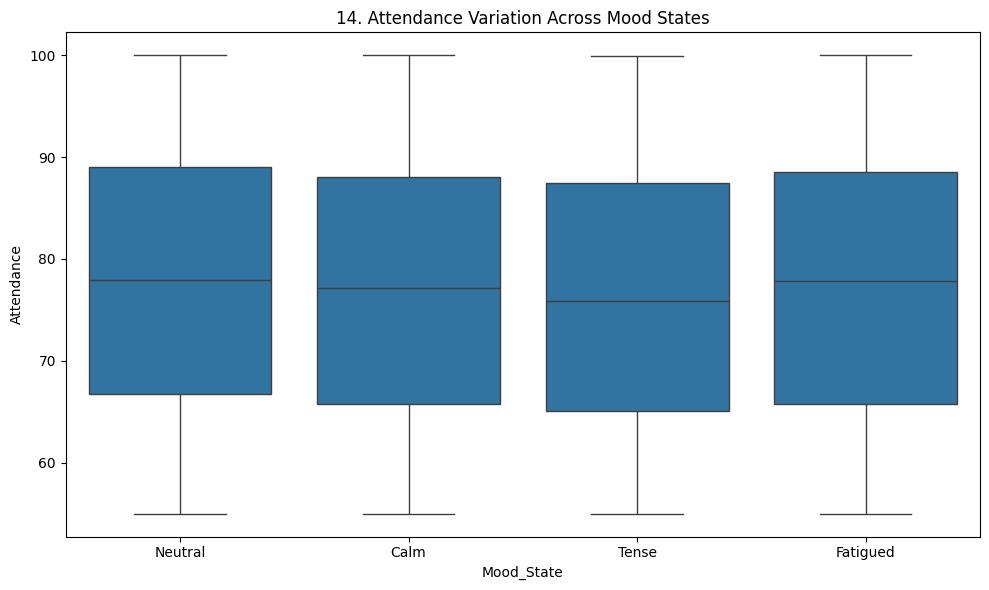

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Mood_State', y='Attendance', data=df)
plt.title(f'{plot_no}. Attendance Variation Across Mood States')
show_fig()
plot_no += 1

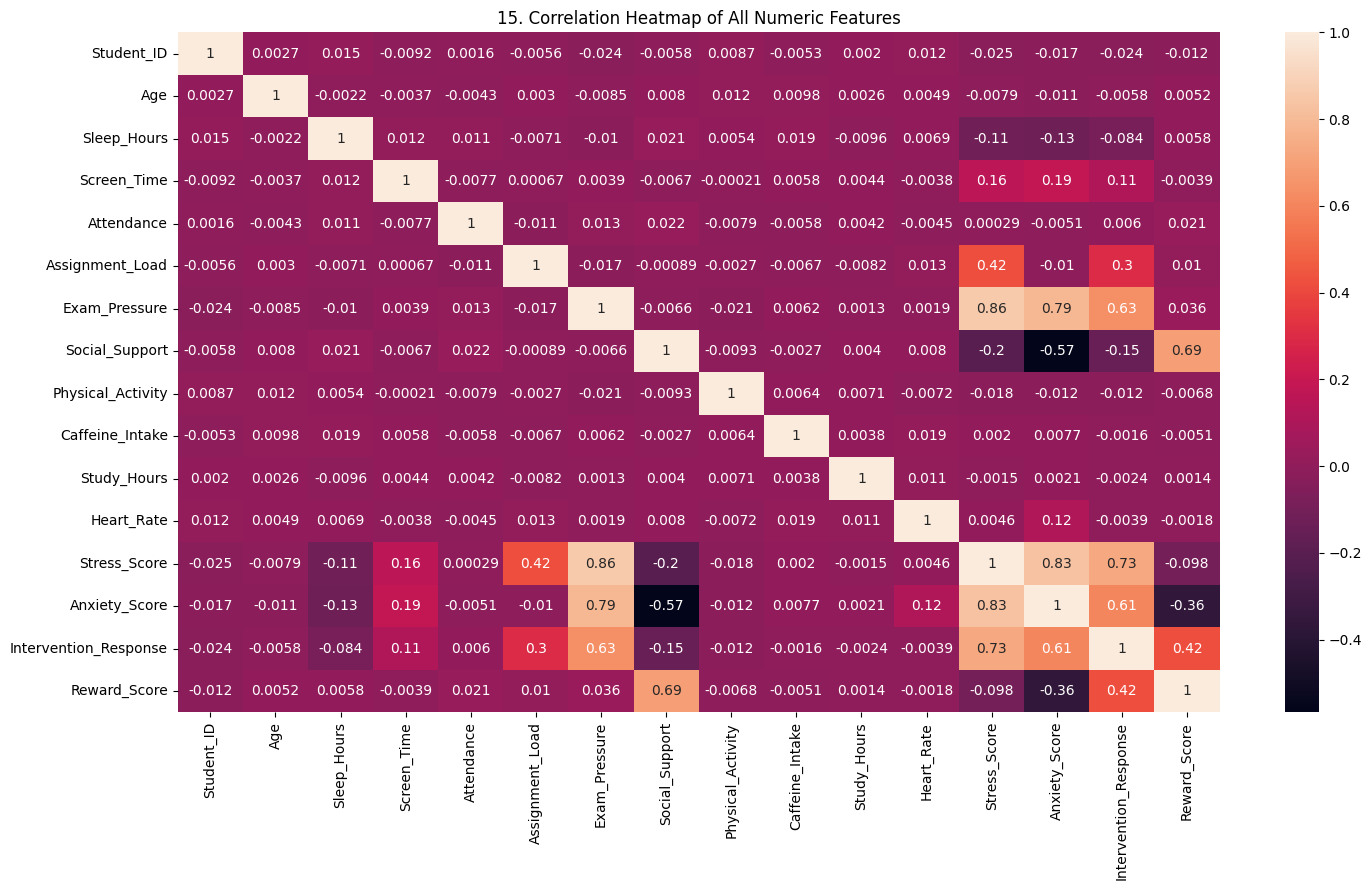

In [27]:
corr = df.corr(numeric_only=True)
fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numeric Features')
show_fig()
plot_no += 1

# Model Training

## select features and target

In [28]:
X = df[['Sleep_Hours','Screen_Time','Attendance','Assignment_Load','Exam_Pressure','Social_Support','Physical_Activity','Caffeine_Intake','Study_Hours','Heart_Rate']]
y = df['Stress_Level']

## convert categorical target into numeric

In [29]:
y = y.map({'Low':0, 'Medium':1, 'High':2})

## split dataset into train and test

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train logistic regression model

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## make predictions

In [33]:
y_pred = model.predict(X_test)

## calculate accuracy

In [34]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9915


## create confusion matrix

In [35]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

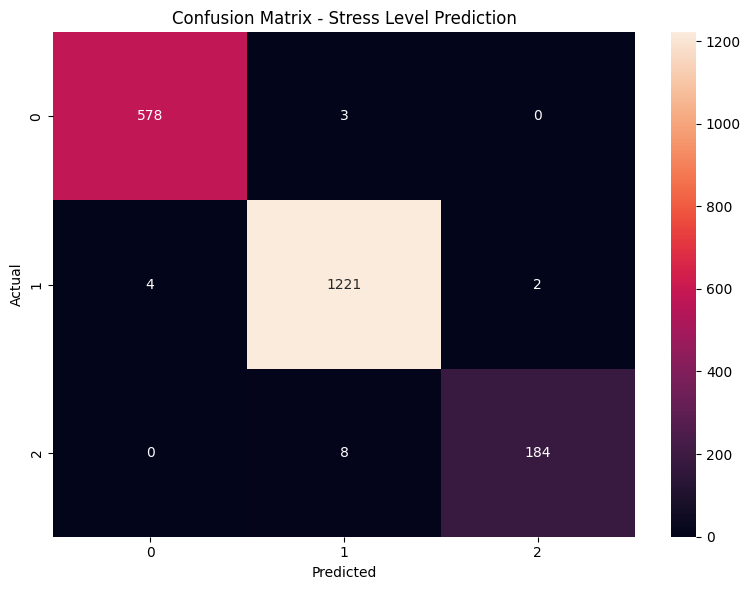

In [36]:
fig = plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Stress Level Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()